# 3장 실습 — 지연을 재는 규약

3권은 3장에서 MMRV를 세우고 남은 열다섯 장이 그 자를 썼다. 이 책도 같은 자리에 왔다. 남은 열다섯 장이 쓸 **보고 규약**을 여기서 정한다.

정할 것이 넷이다.

- 어떤 수를 보고하는가
- 몇 판을 재야 그 수가 믿을 만한가
- 무엇을 버리고 재는가
- 그래서 표가 어떻게 생겼는가

실행 시간은 CPU에서 2분 안팎이다.

In [1]:
%pip install -q koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("torch", torch.__version__)

torch 2.14.0+cu130


## 평균은 왜 안 되는가

1장에서 이미 봤다. 평균이 같은 다섯 조건의 p99가 35에서 159까지 갈렸다. 여기서는 그 이유를 한 줄로 적어 둔다.

**제어 고리는 평균으로 돌지 않는다.** 한 주기의 성패는 그 주기의 추론 시간이 마감을 넘겼는지로 갈리고, 넘긴 주기의 비율을 정하는 것은 분포의 오른쪽 끝이다. 평균은 그 끝에 거의 반응하지 않는다.

그래서 이 책은 매 실험에서 다음 다섯 수를 보고한다.

> **p50 · p99 · 최대 · 마감 놓침률 · 성공률**

앞의 셋은 분포를, 넷째는 마감과의 관계를, 다섯째는 과제를 말한다.

## p99 는 몇 판을 재야 믿을 만한가

여기서 대부분의 보고가 틀어진다. 「100판 돌려서 p99가 48 ms였다」는 문장은 사실상 **한 판의 값을 보고한 것**이다. 100판에서 99번째 백분위는 위에서 두 번째 표본 근처이고, 그 표본은 다음 100판에서 전혀 다른 값이 된다.

참값을 아는 분포를 하나 만들어 확인한다. 1장에서 쓴 것과 같은 모양 — 대부분 24 ms인데 5%가 140 ms로 튀는 분포다.

In [3]:
def sample(rng, n):
    x = rng.normal(24.2, 2.0, n)
    hit = rng.random(n) < .05
    x[hit] = rng.normal(140., 15., int(hit.sum()))
    return np.clip(x, 1., None)


BIG = sample(np.random.default_rng(0), 4_000_000)
TRUE = {q: np.percentile(BIG, q) for q in (50, 99, 99.9)}
print("참값 (표본 400만)")
for q, v in TRUE.items():
    print(pad(f"  p{q}", 12) + pad(f"{v:.1f} ms", 12, True))

참값 (표본 400만)
  p50            24.3 ms
  p99           152.6 ms
  p99.9         170.7 ms


In [4]:
def spread(n, q, trials=400, seed=1):
    rng = np.random.default_rng(seed)
    est = np.array([np.percentile(sample(rng, n), q)
                    for _ in range(trials)])
    return est


print(pad("잰 판 수", 12) + pad("p99 중앙", 12, True)
      + pad("5~95% 범위", 20, True) + pad("참값 대비", 12, True))
NS = (100, 300, 1_000, 3_000, 10_000, 30_000)
SPR = {}
for n in NS:
    e = spread(n, 99)
    SPR[n] = e
    lo, hi = np.percentile(e, [5, 95])
    err = (hi - lo) / TRUE[99] * 100
    print(pad(f"{n:,}", 12) + pad(f"{np.median(e):.0f}", 12, True)
          + pad(f"{lo:.0f} ~ {hi:.0f} ms", 20, True)
          + pad(f"±{err / 2:.0f}%", 12, True))

잰 판 수        p99 중앙          5~95% 범위   참값 대비
100                  145        101 ~ 162 ms        ±20%
300                  151        140 ~ 160 ms         ±7%
1,000                152        146 ~ 158 ms         ±4%
3,000                153        149 ~ 156 ms         ±2%


10,000               153        151 ~ 154 ms         ±1%


30,000               153        152 ~ 154 ms         ±1%


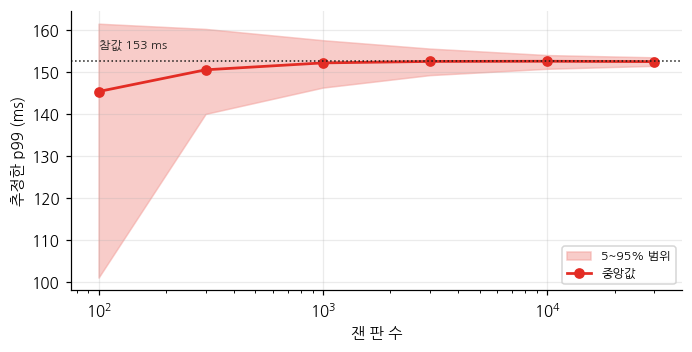

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 3.3))
lo = [np.percentile(SPR[n], 5) for n in NS]
hi = [np.percentile(SPR[n], 95) for n in NS]
md = [np.median(SPR[n]) for n in NS]
ax.fill_between(NS, lo, hi, color=PINK, alpha=.55,
                label="5~95% 범위")
ax.plot(NS, md, "o-", color=RED, lw=1.8, ms=6, label="중앙값")
ax.axhline(TRUE[99], color=INK, lw=1, ls=":")
ax.text(NS[0], TRUE[99] + 3, f"참값 {TRUE[99]:.0f} ms",
        fontsize=8, color=INK)
ax.set_xscale("log")
ax.set_xlabel("잰 판 수")
ax.set_ylabel("추정한 p99 (ms)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 더 뒤쪽 분위수를 원하면 더 많이 재야 한다

p99 는 백 판에 한 번 넘는 값이다. 마감 놓침을 천 판에 한 번으로 묶고 싶다면 봐야 할 것은 p99.9이고, 그것을 재려면 판이 한 자릿수 더 든다.

In [6]:
print(pad("분위수", 10) + pad("잰 판 수", 12, True)
      + pad("5~95% 범위", 22, True))
for q in (99, 99.9):
    for n in (1_000, 10_000, 100_000):
        e = spread(n, q, trials=120)
        lo_, hi_ = np.percentile(e, [5, 95])
        print(pad(f"p{q}", 10) + pad(f"{n:,}", 12, True)
              + pad(f"{lo_:.0f} ~ {hi_:.0f} ms", 22, True))

분위수        잰 판 수            5~95% 범위
p99              1,000          146 ~ 158 ms
p99             10,000          151 ~ 154 ms


p99            100,000          152 ~ 153 ms
p99.9            1,000          161 ~ 176 ms
p99.9           10,000          168 ~ 174 ms


p99.9          100,000          170 ~ 172 ms


## 워밍업을 버린다

두 번째 규약이다. 처음 몇 판은 메모리 할당, 커널 선택, 캐시 예열 때문에 느리다. 그것을 섞어서 재면 꼬리가 가짜로 부풀어 오른다.

In [7]:
class TinyViT(nn.Module):
    def __init__(self, dim=192, depth=6, heads=3, s=224):
        super().__init__()
        self.patch = nn.Conv2d(3, dim, 16, 16)
        self.pos = nn.Parameter(torch.zeros(1, (s // 16) ** 2, dim))
        layer = nn.TransformerEncoderLayer(
            dim, heads, dim * 4, batch_first=True,
            norm_first=True, dropout=0.)
        self.enc = nn.TransformerEncoder(
            layer, depth, enable_nested_tensor=False)
        self.head = nn.Linear(dim, 2)

    def forward(self, x):
        z = self.patch(x).flatten(2).transpose(1, 2) + self.pos
        return self.head(self.enc(z).mean(1))


MODEL = TinyViT().eval()
X = torch.randn(1, 3, 224, 224)
raw = []
for _ in range(200):
    t0 = time.perf_counter_ns()
    with torch.no_grad():
        MODEL(X)
    raw.append((time.perf_counter_ns() - t0) / 1e6)
raw = np.array(raw)

print(pad("판 번호대", 14) + pad("판 수", 8, True)
      + pad("p50 ms", 10, True) + pad("정상 대비", 12, True))
steady = np.percentile(raw[50:], 50)
for label, v in (("1번째", raw[:1]), ("2~5", raw[1:5]),
                 ("6~20", raw[5:20]), ("21~50", raw[20:50]),
                 ("51 이후", raw[50:])):
    p50 = np.percentile(v, 50)
    print(pad(label, 14) + pad(f"{len(v)}", 8, True)
          + pad(f"{p50:.1f}", 10, True)
          + pad(f"{p50 / steady:.2f}배", 12, True))

판 번호대        판 수    p50 ms   정상 대비
1번째                1      17.1      1.51배
2~5                  4      12.2      1.07배
6~20                15      11.5      1.02배
21~50               30      11.3      0.99배
51 이후            150      11.4      1.00배


## 조건을 같은 자리에서 잰다

세 번째 규약은 3권 3장에서 그대로 가져온다. 두 구현을 비교할 때는 **같은 판 수, 같은 시드, 같은 순서**로 재고, 한쪽만 더 오래 돌리지 않는다. 그리고 지연과 성공률을 따로 보고하지 않고 **한 표에** 적는다. 빠른 쪽이 성적을 깎아먹었는지는 두 수를 나란히 놓아야만 보인다.

## 이 책이 쓸 표

네 가지를 합치면 표 하나가 나온다. 남은 열다섯 장이 이 모양을 쓴다.

In [8]:
def report(rows, deadline_ms=50., n_lat=10_000):
    """(이름, 지연 표본 함수, 성공률) 을 규약대로 적는다."""
    print(pad("구현", 16) + pad("p50", 8, True)
          + pad("p99", 8, True) + pad("최대", 8, True)
          + pad("마감 놓침", 12, True) + pad("성공률", 9, True))
    rng = np.random.default_rng(3)
    for name, sampler, ok in rows:
        x = sampler(rng, n_lat)
        miss = float((x > deadline_ms).mean())
        print(pad(name, 16)
              + pad(f"{np.percentile(x, 50):.0f}", 8, True)
              + pad(f"{np.percentile(x, 99):.0f}", 8, True)
              + pad(f"{x.max():.0f}", 8, True)
              + pad(f"{miss * 100:.1f}%", 12, True)
              + pad(f"{ok:.2f}", 9, True))
    print()
    print(f"마감 {deadline_ms:.0f} ms  ·  지연 {n_lat:,}판  "
          f"·  워밍업 20판 제외")


def steady(mu, sd):
    return lambda rng, n: np.clip(rng.normal(mu, sd, n), 1., None)


report([("원본", steady(30., 2.), .90),
        ("압축 A", steady(14., 1.5), .88),
        ("압축 B", sample, .81)])

구현                 p50     p99    최대   마감 놓침   성공률
원본                  30      35      38        0.0%     0.90
압축 A                14      17      20        0.0%     0.88
압축 B                24     154     187        5.2%     0.81

마감 50 ms  ·  지연 10,000판  ·  워밍업 20판 제외


## 정리

**보고하는 수는 다섯이다 — p50, p99, 최대, 마감 놓침률, 성공률.** 평균은 제어 고리의 성패를 정하는 구간에 반응하지 않는다.

**p99에는 판 수가 붙어야 한다.** 100판에서 잰 p99는 참값의 3분의 2까지 낮게 나올 수 있고, 오차가 낙관적인 쪽으로 치우친다. 판 수를 적지 않은 p99는 읽을 수 없는 수다.

**어느 분위수를 볼지는 허용 놓침률이 정한다.** 천 주기에 한 번이어야 한다면 p99.9를 봐야 하고, 그러면 판이 한 자릿수 더 든다.

**워밍업은 버리되 버렸다고 밝힌다.** 그리고 첫 판을 따로 적는다 — 재시작이 잦은 로봇에게는 그것이 진짜 지연이다.

**꼬리는 기계의 부하까지 포함해 잰다.** 이 노트북의 숫자도 돌릴 때마다 달라진다. 조용한 기계에서 잰 p99는 그 기계의 p99이지 로봇의 p99가 아니다.

**지연과 성공률은 한 표에 적는다.** 빠른 구현이 무엇을 내주었는지는 두 수를 나란히 놓아야 보인다.

1부는 여기서 끝난다. 간극을 정의했고 잴 자를 만들었다. 2부는 그 자를 들고 **모델을 작게 만드는 일**로 간다. 그리고 작게 만든 모델이 무엇을 잃는지를 같은 표로 잰다.